In [1]:
!pip install -q timm albumentations

import os, cv2, json, random, copy, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_fscore_support,
    roc_auc_score, roc_curve, precision_recall_curve, balanced_accuracy_score, accuracy_score
)

print("Torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 99.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incomp

In [2]:
class CFG:
    SEED            = 42
    IMG_SIZE        = 224
    BATCH_SIZE      = 32
    EPOCHS          = 150
    EARLY_STOP_PAT  = 25
    WARMUP_EPOCHS   = 5          # epochs with backbone partially frozen
    LR_HEAD         = 1e-4
    LR_BACKBONE     = 2e-5
    WEIGHT_DECAY    = 0.05
    LABEL_SMOOTHING = 0.1
    FOCAL_GAMMA     = 2.0
    MIXUP_ALPHA     = 0.2
    MIXUP_PROB      = 0.5
    EMA_DECAY       = 0.999
    GRAD_CLIP       = 1.0
    TARGET_TOTAL    = 30000     # target size of the balanced training pool
    MAX_OVERSAMPLE  = 10.0      # cap on per-class duplication factor
    SPLIT_STRATEGY  = "lesion-level"   # "lesion-level" (correct) vs "image-level" (leaky, NOT for publication)
    NUM_WORKERS     = 2
    DEVICE          = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed(CFG.SEED)

IMG_DIR_1 = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1"
IMG_DIR_2 = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2"
META_CSV  = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv"

WORK_DIR = "/kaggle/working"
os.makedirs(WORK_DIR, exist_ok=True)
BEST_MODEL_PATH = os.path.join(WORK_DIR, "best_swin_tiny_ham10000.pth")

CLASS_FULLNAME = {
    "akiec": "Actinic keratoses",
    "bcc":   "Basal cell carcinoma",
    "bkl":   "Benign keratosis",
    "df":    "Dermatofibroma",
    "mel":   "Melanoma",
    "nv":    "Melanocytic nevi",
    "vasc":  "Vascular lesions",
}

In [3]:
def build_image_path_lookup(dirs):
    lookup = {}
    for d in dirs:
        for fname in os.listdir(d):
            if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                image_id = os.path.splitext(fname)[0]
                lookup[image_id] = os.path.join(d, fname)
    return lookup

path_lookup = build_image_path_lookup([IMG_DIR_1, IMG_DIR_2])
print(f"Indexed {len(path_lookup)} image files.")

meta = pd.read_csv(META_CSV)
meta["path"] = meta["image_id"].map(path_lookup)
missing = meta["path"].isna().sum()
if missing > 0:
    print(f"Warning: {missing} rows had no matching image file — dropping them.")
meta = meta.dropna(subset=["path"]).reset_index(drop=True)

CLASSES = sorted(meta["dx"].unique())
LABEL2IDX = {c: i for i, c in enumerate(CLASSES)}
IDX2LABEL = {i: c for c, i in LABEL2IDX.items()}
meta["label"] = meta["dx"].map(LABEL2IDX)

print(f"Total images: {len(meta)} | Classes: {CLASSES}")
meta.head()

Indexed 10015 image files.
Total images: 10015 | Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


,lesion_id,image_id,dx,dx_type,age,sex,localization,path,label
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/kaggle/input/datasets/kmader/skin-cancer-mnis...,2


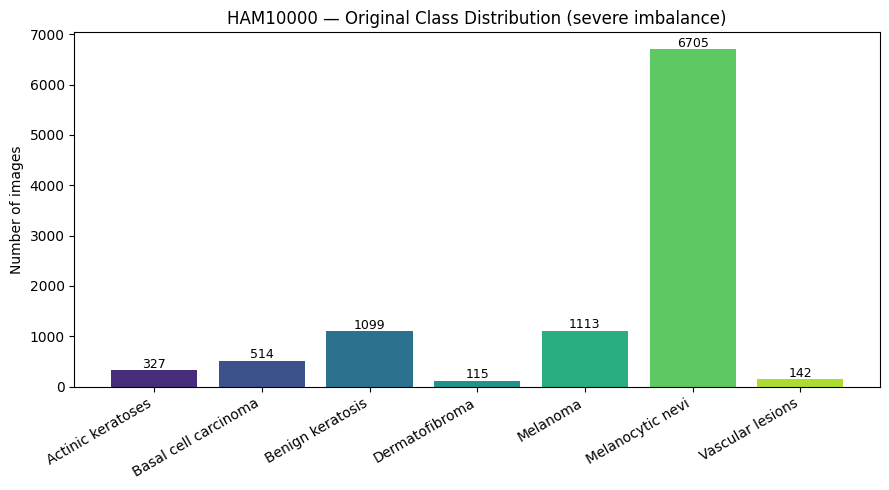

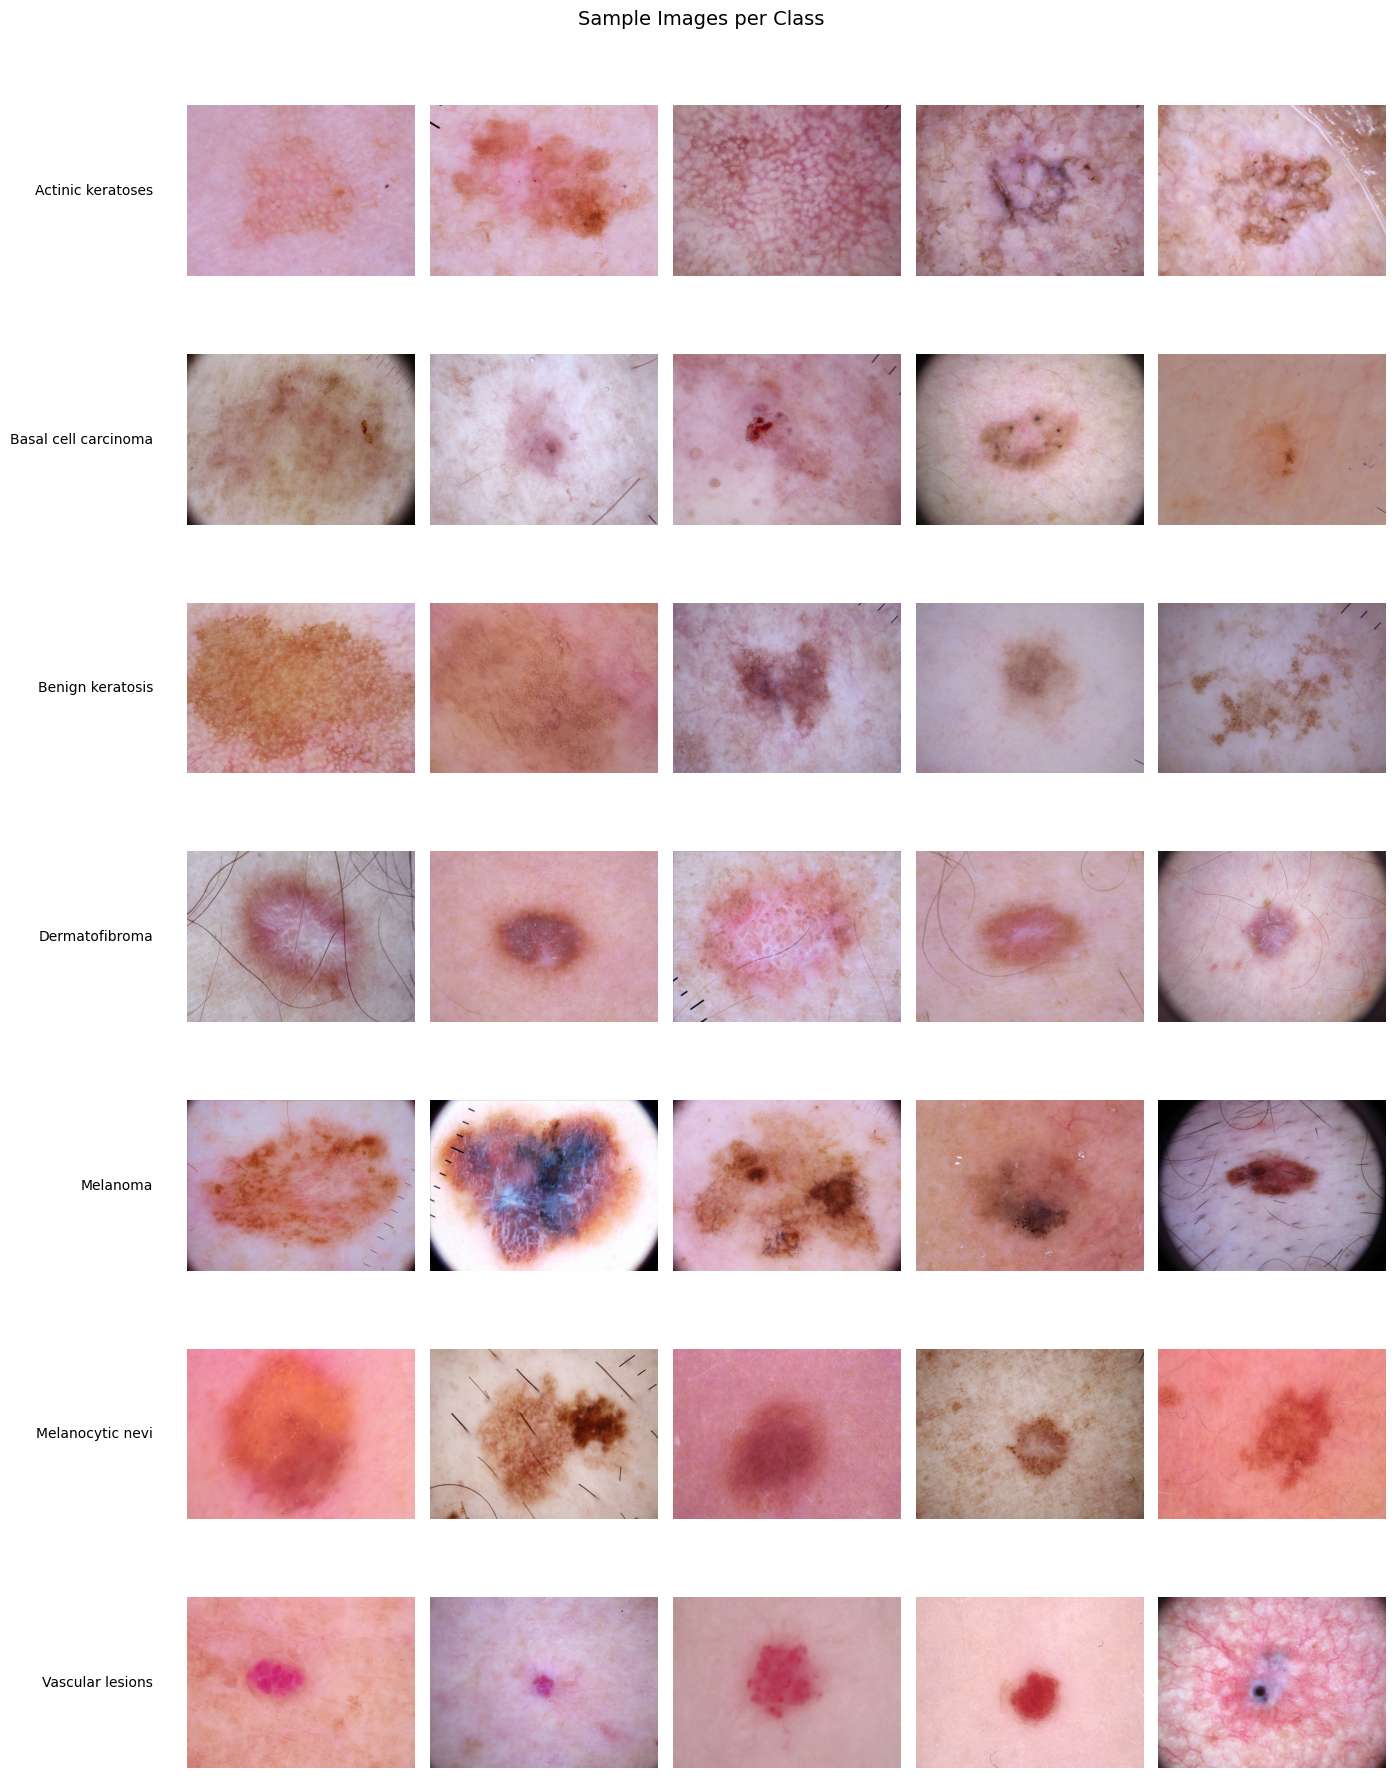

In [4]:
# --- Class distribution (raw) ---
counts = meta["dx"].value_counts().reindex(CLASSES)
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar([CLASS_FULLNAME[c] for c in CLASSES], counts.values, color=sns.color_palette("viridis", len(CLASSES)))
ax.set_ylabel("Number of images")
ax.set_title("HAM10000 — Original Class Distribution (severe imbalance)")
ax.set_xticklabels([CLASS_FULLNAME[c] for c in CLASSES], rotation=30, ha="right")
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, v + 50, str(v), ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, "class_distribution_raw.png"), dpi=150)
plt.show()

# --- Sample images per class ---
fig, axes = plt.subplots(len(CLASSES), 5, figsize=(14, 2.6 * len(CLASSES)))
for i, c in enumerate(CLASSES):
    samples = meta[meta["dx"] == c].sample(min(5, len(meta[meta["dx"] == c])), random_state=CFG.SEED)
    for j, (_, row) in enumerate(samples.iterrows()):
        img = cv2.cvtColor(cv2.imread(row["path"]), cv2.COLOR_BGR2RGB)
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_ylabel(CLASS_FULLNAME[c], fontsize=10)
    for j in range(len(samples), 5):
        axes[i, j].axis("off")
    axes[i, 0].text(-0.15, 0.5, CLASS_FULLNAME[c], fontsize=10, va="center", ha="right",
                     transform=axes[i, 0].transAxes, rotation=0)
plt.suptitle("Sample Images per Class", y=1.0, fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, "sample_images_per_class.png"), dpi=150)
plt.show()

In [5]:
if CFG.SPLIT_STRATEGY == "lesion-level":
    lesion_df = meta.groupby("lesion_id")["dx"].first().reset_index()

    train_lesions, test_lesions = train_test_split(
        lesion_df, test_size=0.15, stratify=lesion_df["dx"], random_state=CFG.SEED
    )
    train_lesions, val_lesions = train_test_split(
        train_lesions, test_size=0.1765, stratify=train_lesions["dx"], random_state=CFG.SEED
    )  # 0.1765 of the remaining 85% ≈ 15% of the original total

    train_df = meta[meta["lesion_id"].isin(train_lesions["lesion_id"])].reset_index(drop=True)
    val_df   = meta[meta["lesion_id"].isin(val_lesions["lesion_id"])].reset_index(drop=True)
    test_df  = meta[meta["lesion_id"].isin(test_lesions["lesion_id"])].reset_index(drop=True)

else:  # image-level — NOT recommended, leaks lesions across splits, inflates accuracy
    train_df, test_df = train_test_split(meta, test_size=0.15, stratify=meta["dx"], random_state=CFG.SEED)
    train_df, val_df  = train_test_split(train_df, test_size=0.1765, stratify=train_df["dx"], random_state=CFG.SEED)

print(f"Train: {len(train_df)} images | Val: {len(val_df)} images | Test: {len(test_df)} images")
print("Train class distribution:\n", train_df["dx"].value_counts())

# Sanity check: confirm zero lesion overlap between splits
if CFG.SPLIT_STRATEGY == "lesion-level":
    overlap = set(train_df.lesion_id) & set(val_df.lesion_id) & set(test_df.lesion_id)
    assert len(set(train_df.lesion_id) & set(test_df.lesion_id)) == 0, "Leakage: train/test lesion overlap!"
    assert len(set(train_df.lesion_id) & set(val_df.lesion_id)) == 0, "Leakage: train/val lesion overlap!"
    print("✓ No lesion leakage between splits confirmed.")

Train: 7054 images | Val: 1464 images | Test: 1497 images
Train class distribution:
 dx
nv       4730
mel       777
bkl       775
bcc       365
akiec     233
vasc       98
df         76
Name: count, dtype: int64
✓ No lesion leakage between splits confirmed.


Raw train counts:      {'nv': 4730, 'mel': 777, 'bkl': 775, 'bcc': 365, 'akiec': 233, 'vasc': 98, 'df': 76}
Balanced targets:      {'nv': np.int64(20116), 'mel': np.int64(3305), 'bkl': np.int64(3296), 'bcc': np.int64(1552), 'akiec': np.int64(991), 'vasc': np.int64(417), 'df': np.int64(323)}
Realized total:        30000
Final balanced training pool size: 30000


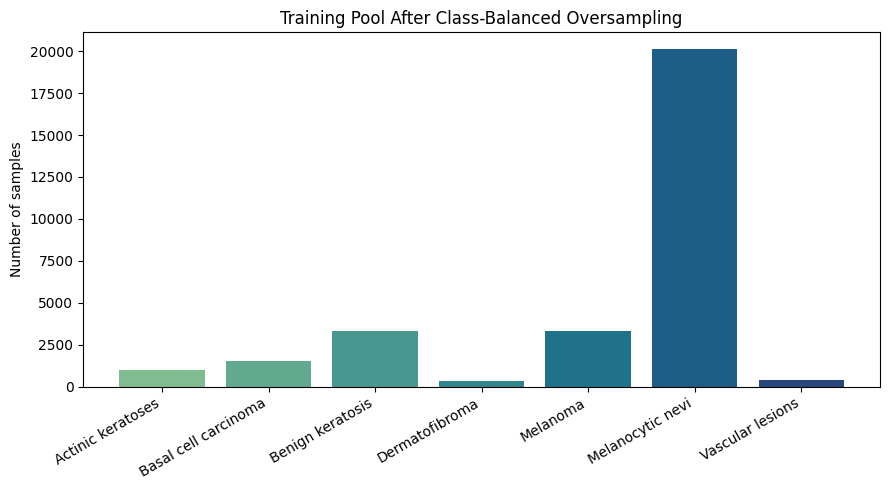

In [6]:
def compute_balanced_oversample_counts(class_counts: dict, total_target=30000, max_oversample=10.0):
    """
    Finds a global multiplier m (via binary search) such that summing
    min(count_i * m, count_i * max_oversample) across classes ≈ total_target.
    The cap prevents rare classes (e.g. df, vasc) from being duplicated so many
    times that the model just memorizes a handful of unique lesions.
    """
    classes = list(class_counts.keys())
    counts = np.array([class_counts[c] for c in classes], dtype=float)

    def total_for_multiplier(m):
        targets = np.minimum(counts * m, counts * max_oversample)
        targets = np.maximum(targets, counts)
        return targets.sum()

    lo, hi = 1.0, 50.0
    for _ in range(60):
        mid = (lo + hi) / 2
        if total_for_multiplier(mid) < total_target:
            lo = mid
        else:
            hi = mid
    m_final = (lo + hi) / 2
    targets = np.minimum(counts * m_final, counts * max_oversample)
    targets = np.maximum(targets, counts).round().astype(int)
    return dict(zip(classes, targets))

raw_train_counts = train_df["dx"].value_counts().to_dict()
balanced_targets = compute_balanced_oversample_counts(raw_train_counts, CFG.TARGET_TOTAL, CFG.MAX_OVERSAMPLE)

print("Raw train counts:     ", raw_train_counts)
print("Balanced targets:     ", balanced_targets)
print("Realized total:       ", sum(balanced_targets.values()))

# Build the oversampled index list (each entry re-augmented independently at __getitem__ time)
balanced_paths, balanced_labels = [], []
for c in CLASSES:
    class_df = train_df[train_df["dx"] == c]
    target_n = balanced_targets[c]
    reps = target_n // len(class_df)
    remainder = target_n % len(class_df)
    idx = list(class_df.index) * reps + list(np.random.choice(class_df.index, remainder, replace=False))
    balanced_paths.extend(meta.loc[idx, "path"].tolist())
    balanced_labels.extend([LABEL2IDX[c]] * len(idx))

print(f"Final balanced training pool size: {len(balanced_paths)}")

# Visualize balanced distribution
fig, ax = plt.subplots(figsize=(9, 5))
vals = [balanced_targets[c] for c in CLASSES]
ax.bar([CLASS_FULLNAME[c] for c in CLASSES], vals, color=sns.color_palette("crest", len(CLASSES)))
ax.set_title("Training Pool After Class-Balanced Oversampling")
ax.set_ylabel("Number of samples")
ax.set_xticklabels([CLASS_FULLNAME[c] for c in CLASSES], rotation=30, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, "class_distribution_balanced.png"), dpi=150)
plt.show()

In [7]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = A.Compose([
    A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, rotate_limit=25,
                        border_mode=cv2.BORDER_REFLECT, p=0.6),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.4),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

eval_transform = A.Compose([
    A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

class HAM10000Dataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = self.transform(image=img)["image"]
        label = self.labels[idx]
        return img, label

train_dataset = HAM10000Dataset(balanced_paths, balanced_labels, train_transform)
val_dataset   = HAM10000Dataset(val_df["path"].tolist(), val_df["label"].tolist(), eval_transform)
test_dataset  = HAM10000Dataset(test_df["path"].tolist(), test_df["label"].tolist(), eval_transform)

train_loader = DataLoader(train_dataset, batch_size=CFG.BATCH_SIZE, shuffle=True,
                           num_workers=CFG.NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False,
                           num_workers=CFG.NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False,
                           num_workers=CFG.NUM_WORKERS, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Train batches: 937 | Val batches: 46 | Test batches: 47


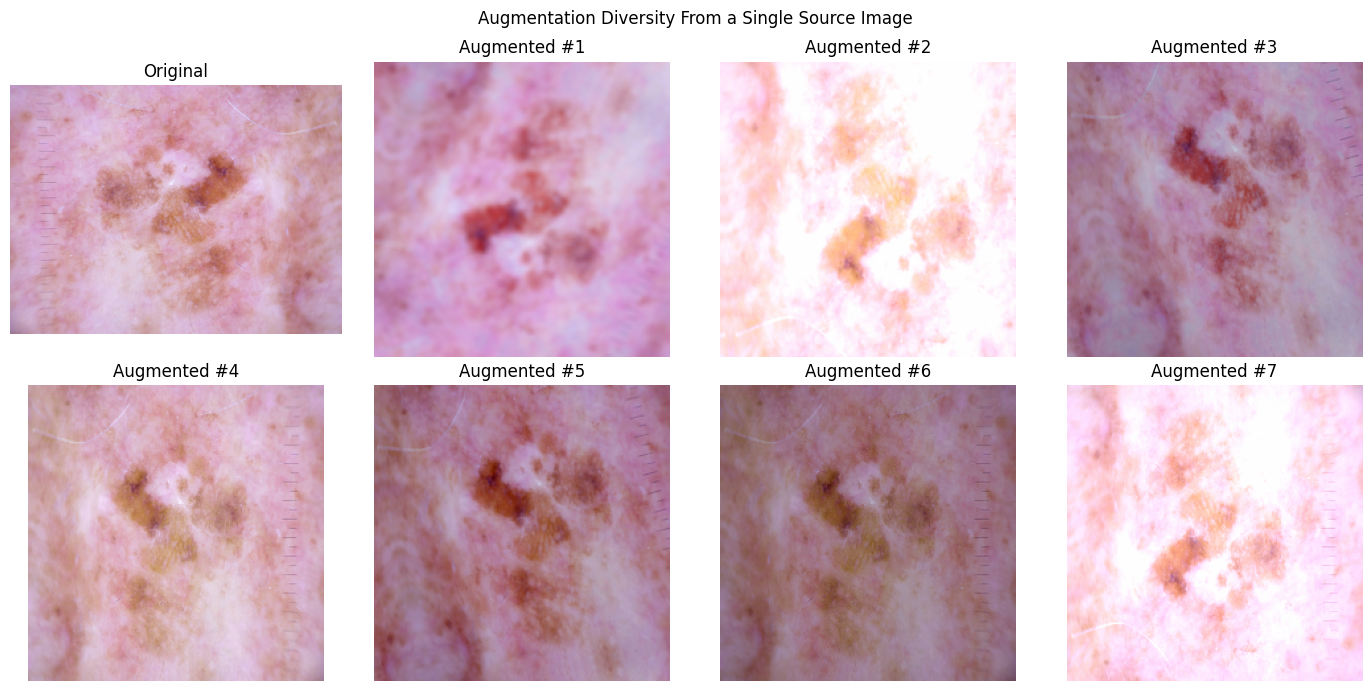

In [8]:
sample_path = train_df.iloc[0]["path"]
sample_img = cv2.cvtColor(cv2.imread(sample_path), cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes[0, 0].imshow(sample_img); axes[0, 0].set_title("Original"); axes[0, 0].axis("off")
for i in range(1, 8):
    aug = train_transform(image=sample_img)["image"]
    aug_np = aug.permute(1, 2, 0).numpy()
    aug_np = (aug_np * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)).clip(0, 1)
    axes[i // 4, i % 4].imshow(aug_np)
    axes[i // 4, i % 4].set_title(f"Augmented #{i}")
    axes[i // 4, i % 4].axis("off")
plt.suptitle("Augmentation Diversity From a Single Source Image")
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, "augmentation_examples.png"), dpi=150)
plt.show()

In [9]:
NUM_CLASSES = len(CLASSES)

model = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=True,
    num_classes=NUM_CLASSES,
    drop_rate=0.3,
    drop_path_rate=0.2,
).to(CFG.DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,} | Trainable: {trainable_params:,}")

def set_warmup_freeze(model, freeze: bool):
    """During warmup epochs, freeze patch_embed + first two stages so the
    randomly-initialized head doesn't push noisy gradients through the whole
    pretrained backbone before it has learned anything useful."""
    for name, param in model.named_parameters():
        if any(k in name for k in ["patch_embed", "layers.0", "layers.1"]):
            param.requires_grad = not freeze

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Total params: 27,524,737 | Trainable: 27,524,737


In [10]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.alpha,
                              label_smoothing=self.label_smoothing, reduction="none")
        pt = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()

# Mild class weights (sqrt-inverse frequency) — kept gentle since oversampling
# already does most of the balancing work; stacking two strong corrections
# tends to over-correct and hurt the majority class.
class_counts_arr = np.array([raw_train_counts[c] for c in CLASSES])
class_weights = torch.tensor(np.sqrt(class_counts_arr.sum() / class_counts_arr), dtype=torch.float32).to(CFG.DEVICE)
class_weights = class_weights / class_weights.mean()

criterion = FocalLoss(alpha=class_weights, gamma=CFG.FOCAL_GAMMA, label_smoothing=CFG.LABEL_SMOOTHING)

head_params = [p for n, p in model.named_parameters() if "head" in n]
backbone_params = [p for n, p in model.named_parameters() if "head" not in n]

optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": CFG.LR_BACKBONE},
    {"params": head_params,     "lr": CFG.LR_HEAD},
], weight_decay=CFG.WEIGHT_DECAY)

from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR
warmup_sched = LinearLR(optimizer, start_factor=0.1, total_iters=CFG.WARMUP_EPOCHS)
cosine_sched = CosineAnnealingLR(optimizer, T_max=CFG.EPOCHS - CFG.WARMUP_EPOCHS, eta_min=1e-7)
scheduler = SequentialLR(optimizer, schedulers=[warmup_sched, cosine_sched], milestones=[CFG.WARMUP_EPOCHS])

scaler = torch.cuda.amp.GradScaler()

class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.clone().detach() for k, v in model.state_dict().items()}

    def update(self, model):
        with torch.no_grad():
            for k, v in model.state_dict().items():
                if v.dtype.is_floating_point:
                    self.shadow[k].mul_(self.decay).add_(v.detach(), alpha=1 - self.decay)
                else:
                    self.shadow[k] = v.clone()

    def apply_to(self, model):
        model.load_state_dict(self.shadow, strict=True)

ema = EMA(model, decay=CFG.EMA_DECAY)

def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    return mixed_x, y, y[index], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [11]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, ema, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, leave=False, desc="train"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        use_mixup = np.random.rand() < CFG.MIXUP_PROB
        if use_mixup:
            images, y_a, y_b, lam = mixup_data(images, labels, CFG.MIXUP_ALPHA)

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = mixup_criterion(criterion, outputs, y_a, y_b, lam) if use_mixup else criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        ema.update(model)

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels, all_probs = 0.0, [], [], []
    for images, labels in tqdm(loader, leave=False, desc="eval"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        probs = F.softmax(outputs, dim=1)
        all_preds.extend(probs.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    all_preds, all_labels, all_probs = np.array(all_preds), np.array(all_labels), np.array(all_probs)
    acc = accuracy_score(all_labels, all_preds)
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    _, _, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average="macro", zero_division=0)
    return {
        "loss": total_loss / len(all_labels), "acc": acc, "bal_acc": bal_acc,
        "macro_f1": f1, "preds": all_preds, "labels": all_labels, "probs": all_probs,
    }

def evaluate_with_ema(model, ema, loader, criterion, device):
    raw_state = copy.deepcopy(model.state_dict())
    ema.apply_to(model)
    metrics = evaluate(model, loader, criterion, device)
    model.load_state_dict(raw_state)
    return metrics

In [12]:
history = {k: [] for k in ["train_loss", "train_acc", "val_loss", "val_acc", "val_bal_acc", "val_f1", "lr"]}
best_f1, patience_counter = -1.0, 0

for epoch in range(CFG.EPOCHS):
    set_warmup_freeze(model, freeze=(epoch < CFG.WARMUP_EPOCHS))

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler, ema, CFG.DEVICE)
    val_metrics = evaluate_with_ema(model, ema, val_loader, criterion, CFG.DEVICE)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_metrics["loss"])
    history["val_acc"].append(val_metrics["acc"])
    history["val_bal_acc"].append(val_metrics["bal_acc"])
    history["val_f1"].append(val_metrics["macro_f1"])
    history["lr"].append(optimizer.param_groups[0]["lr"])

    print(f"Epoch {epoch+1:3d}/{CFG.EPOCHS} | "
          f"train_loss {train_loss:.4f} acc {train_acc:.4f} | "
          f"val_loss {val_metrics['loss']:.4f} acc {val_metrics['acc']:.4f} "
          f"bal_acc {val_metrics['bal_acc']:.4f} f1 {val_metrics['macro_f1']:.4f}")

    if val_metrics["macro_f1"] > best_f1:
        best_f1 = val_metrics["macro_f1"]
        patience_counter = 0
        torch.save({
            "model_state": ema.shadow,
            "epoch": epoch,
            "val_f1": best_f1,
            "val_acc": val_metrics["acc"],
            "classes": CLASSES,
        }, BEST_MODEL_PATH)
        print(f"  ↳ New best model saved (val_f1={best_f1:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= CFG.EARLY_STOP_PAT:
            print(f"Early stopping at epoch {epoch+1} (no improvement for {CFG.EARLY_STOP_PAT} epochs).")
            break

with open(os.path.join(WORK_DIR, "training_history.json"), "w") as f:
    json.dump(history, f, indent=2)

train:   0%|          | 0/937 [00:00<?, ?it/s]

eval:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch   1/150 | train_loss 0.3652 acc 0.5426 | val_loss 0.4210 acc 0.4173 bal_acc 0.1648 f1 0.1600
  ↳ New best model saved (val_f1=0.1600)


train:   0%|          | 0/937 [00:00<?, ?it/s]

eval:   0%|          | 0/46 [00:00<?, ?it/s]

...

eval:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch  78/150 | train_loss 0.0682 acc 0.8709 | val_loss 0.6916 acc 0.6093 bal_acc 0.2636 f1 0.2652


train:   0%|          | 0/937 [00:00<?, ?it/s]

eval:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch  79/150 | train_loss 0.0659 acc 0.8679 | val_loss 0.6926 acc 0.6107 bal_acc 0.2639 f1 0.2669
Early stopping at epoch 79 (no improvement for 25 epochs).


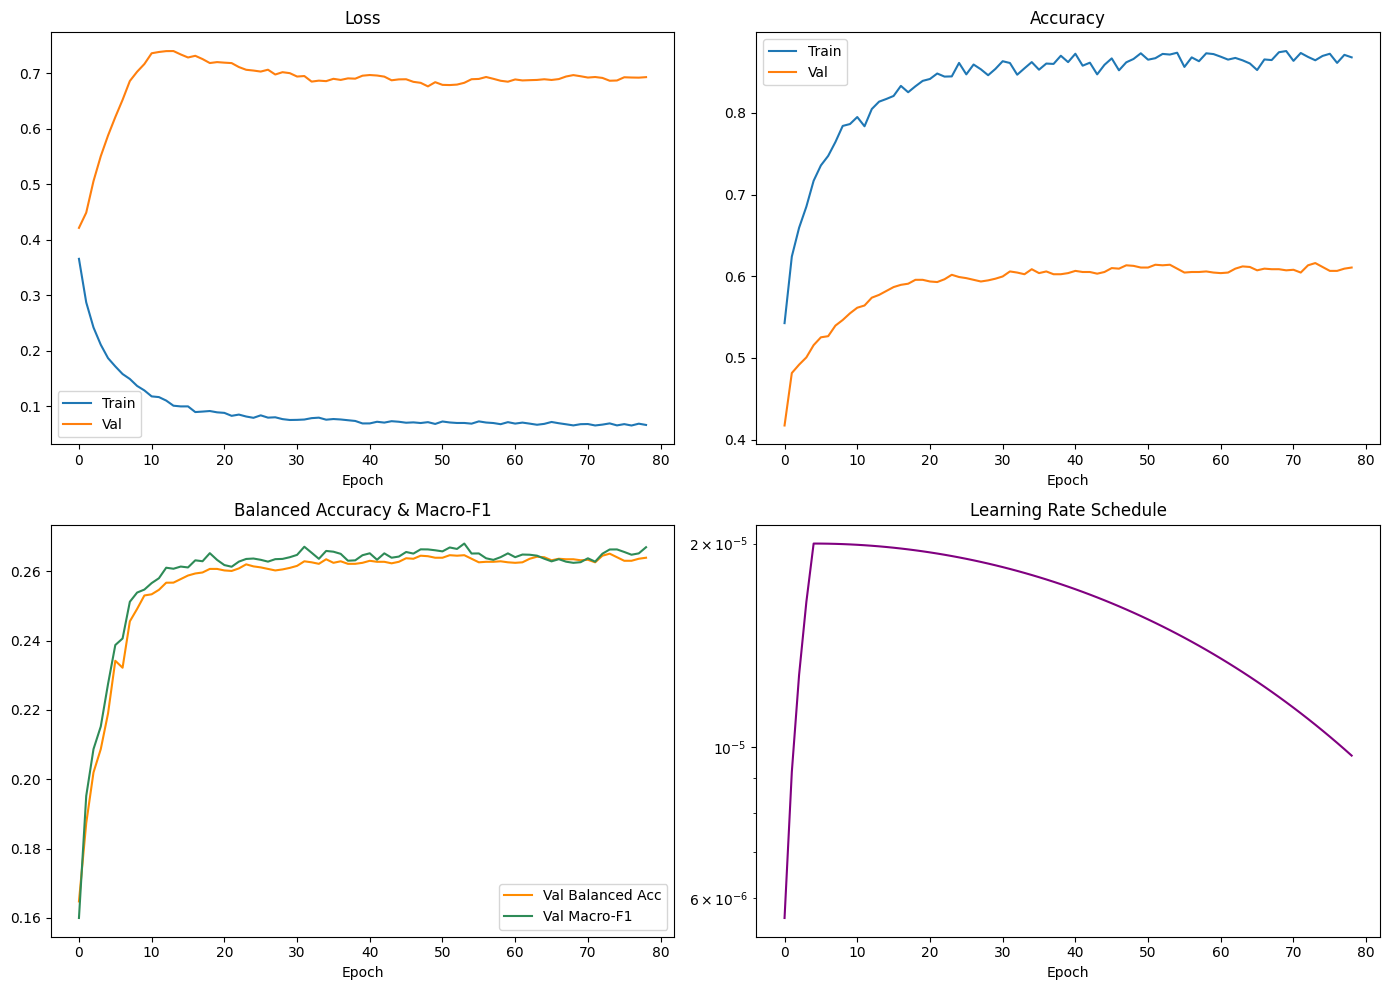

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(history["train_loss"], label="Train"); axes[0,0].plot(history["val_loss"], label="Val")
axes[0,0].set_title("Loss"); axes[0,0].set_xlabel("Epoch"); axes[0,0].legend()

axes[0,1].plot(history["train_acc"], label="Train"); axes[0,1].plot(history["val_acc"], label="Val")
axes[0,1].set_title("Accuracy"); axes[0,1].set_xlabel("Epoch"); axes[0,1].legend()

axes[1,0].plot(history["val_bal_acc"], label="Val Balanced Acc", color="darkorange")
axes[1,0].plot(history["val_f1"], label="Val Macro-F1", color="seagreen")
axes[1,0].set_title("Balanced Accuracy & Macro-F1"); axes[1,0].set_xlabel("Epoch"); axes[1,0].legend()

axes[1,1].plot(history["lr"], color="purple")
axes[1,1].set_title("Learning Rate Schedule"); axes[1,1].set_xlabel("Epoch"); axes[1,1].set_yscale("log")

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, "training_curves.png"), dpi=150)
plt.show()

In [14]:
checkpoint = torch.load(BEST_MODEL_PATH, map_location=CFG.DEVICE)
model.load_state_dict(checkpoint["model_state"])
model.eval()
print(f"Loaded best checkpoint from epoch {checkpoint['epoch']+1} (val_f1={checkpoint['val_f1']:.4f})")

test_metrics = evaluate(model, test_loader, criterion, CFG.DEVICE)
print(f"\n=== TEST SET RESULTS (truly unseen lesions) ===")
print(f"Accuracy:          {test_metrics['acc']:.4f}")
print(f"Balanced accuracy: {test_metrics['bal_acc']:.4f}")
print(f"Macro F1:          {test_metrics['macro_f1']:.4f}")

report = classification_report(test_metrics["labels"], test_metrics["preds"],
                                target_names=[CLASS_FULLNAME[c] for c in CLASSES], digits=4)
print(report)
with open(os.path.join(WORK_DIR, "classification_report.txt"), "w") as f:
    f.write(report)

Loaded best checkpoint from epoch 54 (val_f1=0.2680)


eval:   0%|          | 0/47 [00:00<?, ?it/s]


=== TEST SET RESULTS (truly unseen lesions) ===
Accuracy:          0.5919
Balanced accuracy: 0.2623
Macro F1:          0.2528
                      precision    recall  f1-score   support

   Actinic keratoses     0.0000    0.0000    0.0000        51
Basal cell carcinoma     0.0000    0.0000    0.0000        77
    Benign keratosis     0.5735    0.7452    0.6482       157
      Dermatofibroma     0.0000    0.0000    0.0000        22
            Melanoma     0.3385    0.3869    0.3611       168
    Melanocytic nevi     0.8263    0.7040    0.7603      1000
    Vascular lesions     0.0000    0.0000    0.0000        22

            accuracy                         0.5919      1497
           macro avg     0.2483    0.2623    0.2528      1497
        weighted avg     0.6501    0.5919    0.6164      1497



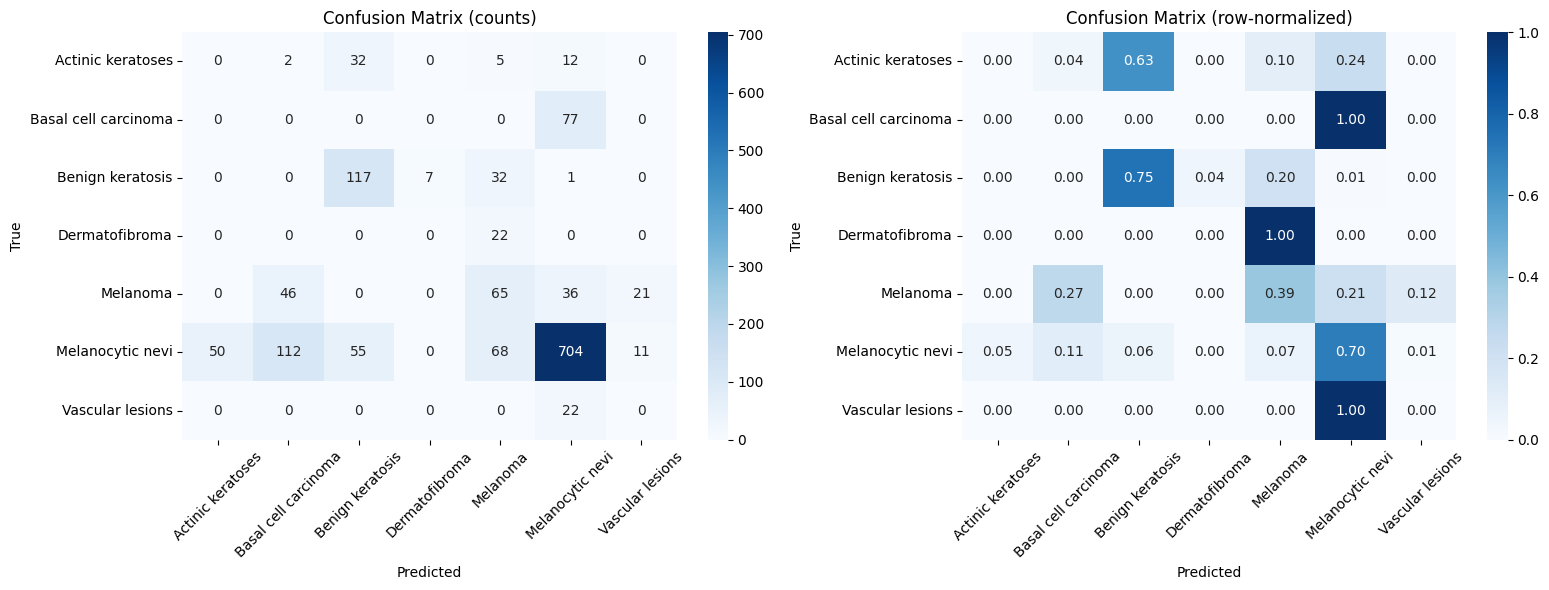

In [15]:
cm = confusion_matrix(test_metrics["labels"], test_metrics["preds"])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[CLASS_FULLNAME[c] for c in CLASSES],
            yticklabels=[CLASS_FULLNAME[c] for c in CLASSES], ax=axes[0])
axes[0].set_title("Confusion Matrix (counts)"); axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=[CLASS_FULLNAME[c] for c in CLASSES],
            yticklabels=[CLASS_FULLNAME[c] for c in CLASSES], ax=axes[1])
axes[1].set_title("Confusion Matrix (row-normalized)"); axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

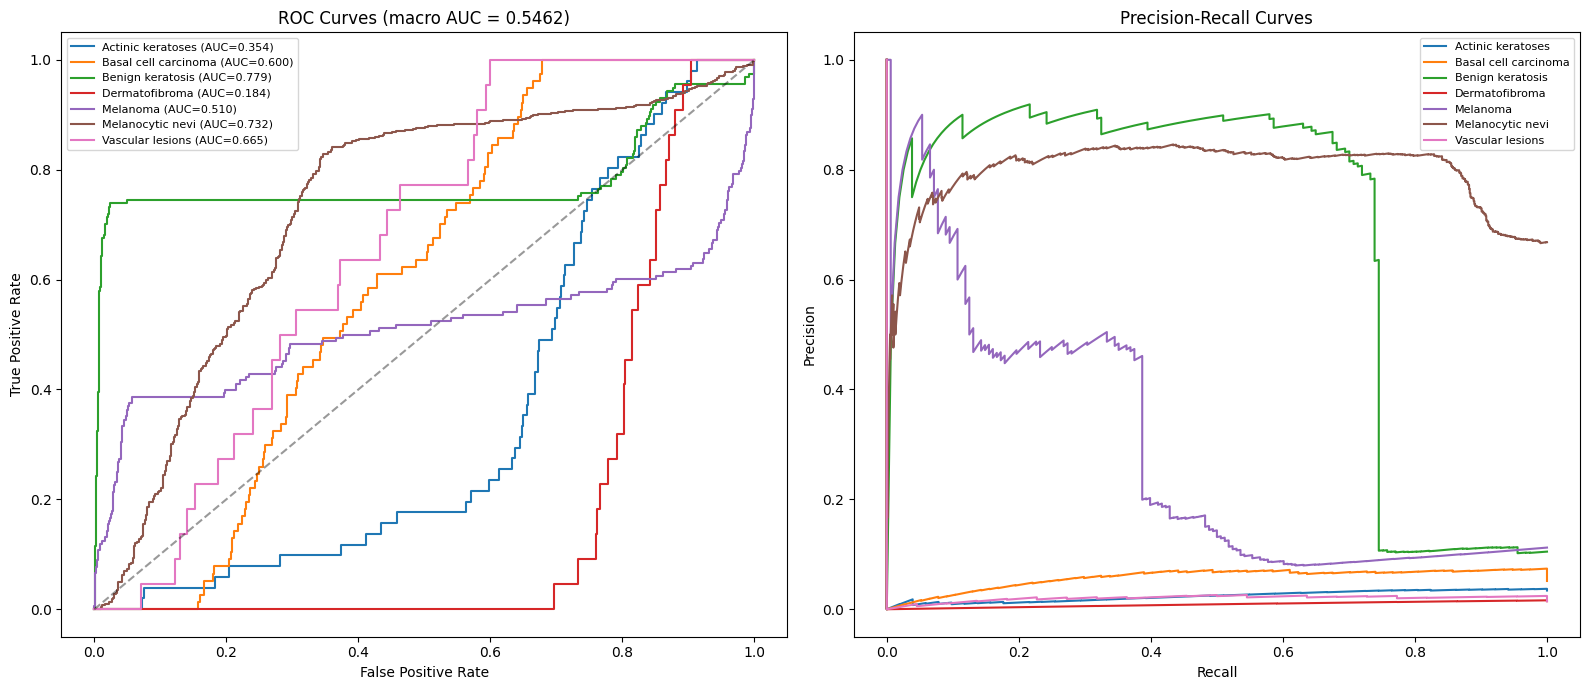

In [16]:
y_true_onehot = np.eye(NUM_CLASSES)[test_metrics["labels"]]
probs = test_metrics["probs"]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
macro_auc = roc_auc_score(y_true_onehot, probs, average="macro", multi_class="ovr")

for i, c in enumerate(CLASSES):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], probs[:, i])
    auc_i = roc_auc_score(y_true_onehot[:, i], probs[:, i])
    axes[0].plot(fpr, tpr, label=f"{CLASS_FULLNAME[c]} (AUC={auc_i:.3f})")

    prec, rec, _ = precision_recall_curve(y_true_onehot[:, i], probs[:, i])
    axes[1].plot(rec, prec, label=CLASS_FULLNAME[c])

axes[0].plot([0,1],[0,1],"k--", alpha=0.4)
axes[0].set_title(f"ROC Curves (macro AUC = {macro_auc:.4f})")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate"); axes[0].legend(fontsize=8)

axes[1].set_title("Precision-Recall Curves")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, "roc_pr_curves.png"), dpi=150)
plt.show()

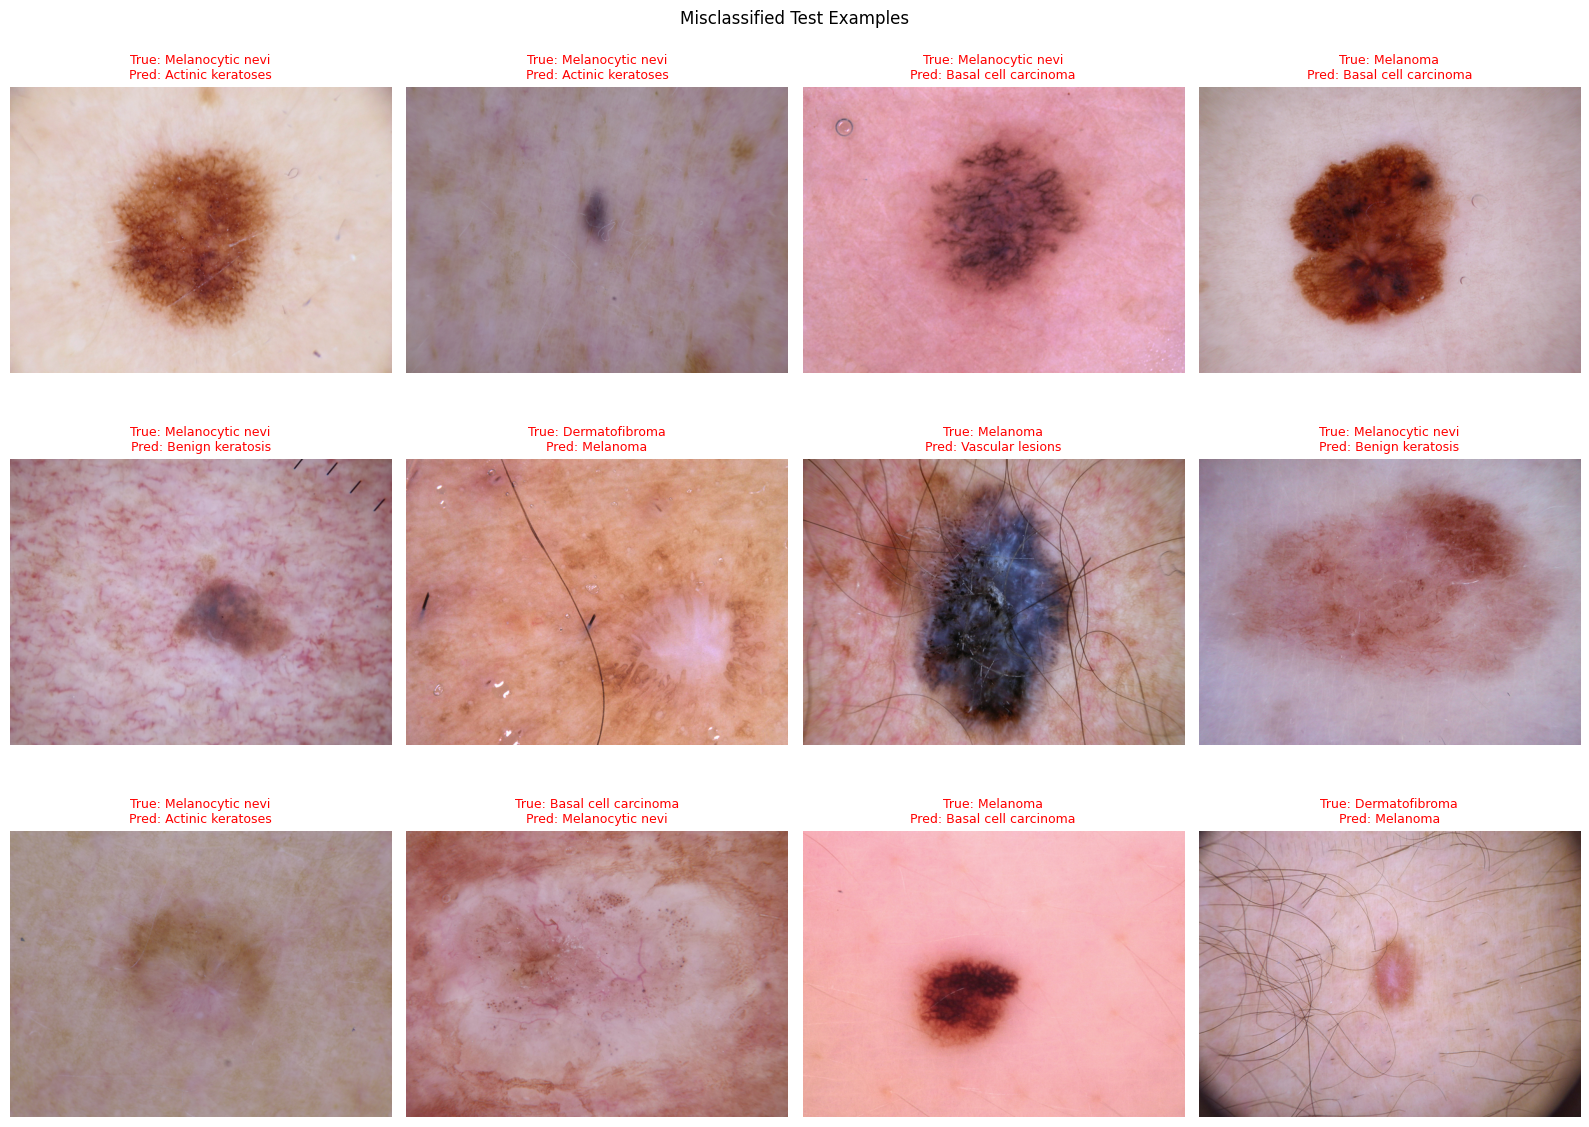

In [17]:
mis_idx = np.where(test_metrics["preds"] != test_metrics["labels"])[0]
n_show = min(12, len(mis_idx))
sample_idx = np.random.choice(mis_idx, n_show, replace=False) if n_show > 0 else []

if n_show > 0:
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    for ax, idx in zip(axes.flatten(), sample_idx):
        path = test_df.iloc[idx]["path"]
        img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        ax.imshow(img); ax.axis("off")
        true_c = CLASS_FULLNAME[IDX2LABEL[test_metrics["labels"][idx]]]
        pred_c = CLASS_FULLNAME[IDX2LABEL[test_metrics["preds"][idx]]]
        ax.set_title(f"True: {true_c}\nPred: {pred_c}", fontsize=9, color="red")
    for ax in axes.flatten()[n_show:]:
        ax.axis("off")
    plt.suptitle("Misclassified Test Examples")
    plt.tight_layout()
    plt.savefig(os.path.join(WORK_DIR, "misclassified_examples.png"), dpi=150)
    plt.show()
else:
    print("No misclassified examples found in this sample.")

In [18]:
summary = {
    "test_accuracy": float(test_metrics["acc"]),
    "test_balanced_accuracy": float(test_metrics["bal_acc"]),
    "test_macro_f1": float(test_metrics["macro_f1"]),
    "test_macro_auc": float(macro_auc),
    "best_epoch": int(checkpoint["epoch"] + 1),
    "split_strategy": CFG.SPLIT_STRATEGY,
}
with open(os.path.join(WORK_DIR, "final_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))
print(f"\nAll artifacts saved to {WORK_DIR}/")

{
  "test_accuracy": 0.5918503674014696,
  "test_balanced_accuracy": 0.2623039559772954,
  "test_macro_f1": 0.2527956766228785,
  "test_macro_auc": 0.5461710938283536,
  "best_epoch": 54,
  "split_strategy": "lesion-level"
}

All artifacts saved to /kaggle/working/
